In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import curve_fit

**Task 1 | load data**

Goal: Make a function to load the data given the filepath and return only the columns we will use (data/production columns).

Function Structure:

Arguments: filepath to the data, name of production column, name of the date column, name of the well we will use, name of the column that have different well names to filter the data with.

Return: Dataframe with only two columns: date, production.

In [ ]:
# function to load the data
def load_data(filepath, well_names_col, well_name, prod_col_name, date_col_name):

    df = pd.read_excel(filepath)

    # filtering to the specific well
    df = df[ df[well_names_col] == well_name ][[date_col_name, prod_col_name]]

    # rename columns
    df.columns = ["date", "production"]

    # return the dataframe with only the two columns [ data, production ], and they must be with the same name
    return df

In [ ]:
# test your function here
df = load_data("/content/Volve production data.xlsx", "NPD_WELL_BORE_NAME", "15/9-F-14", "BORE_OIL_VOL", "DATEPRD")
df.head()

,date,production
4967,2008-02-12,0.0
4968,2008-02-13,0.0
4969,2008-02-14,0.0
4970,2008-02-15,0.0
4971,2008-02-16,0.0


In [ ]:
# don't modify this code, just run it
assert len(df.columns) == 2, "make sure you have only two columns"
assert list(df.columns) == ["date", "production"], "make shure you rename the columns to [data] and [production] columns"

<Axes: xlabel='date'>

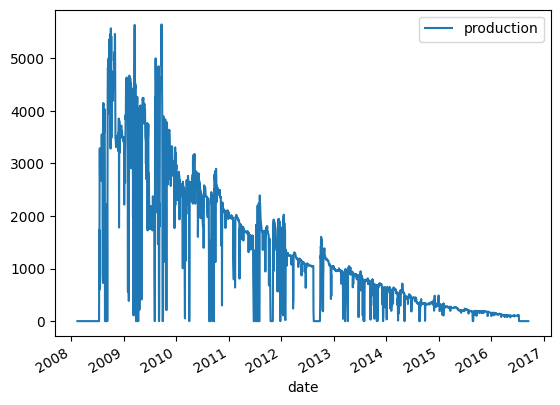

In [ ]:
df.plot(x="date",y="production")

**Task 2 | remove the outliers**

Goal: Make a function that takes the data and removes the outliers of a given column.

Function Structure:

Arguments: df, column_name (which will be the production column by default).

Return: A new dataframe.

In [ ]:
# remove the outlier from the production data
def remove_outliers(df, col_name="production"):
  df = df[df[col_name] != 0]
  return df

In [ ]:
#test
df_removed = remove_outliers(df)
df_removed.head()

,date,production
5118,2008-07-13,1735.26
5119,2008-07-14,592.36
5120,2008-07-15,2532.21
5121,2008-07-16,3030.71
5122,2008-07-17,3288.08


**Task 3 | Data Smoothing**

Goal: Make a function to smooth a given column using the moving average and remove the NaN values from the data.

Function Structure:

Arguments: df, column_name (default is the production column), window_size.

Return: A new dataframe with three columns: date, production, and production_smoothed.

In [ ]:
# data smoothing
def smooth(df, col_name="production", window_size=100):

    df[col_name + "_smoothed"] = df[col_name].rolling(window=window_size, center=True).mean()

    # dropping nan values
    df = df.dropna()

    return df

In [ ]:
# test your code here
df_smoothed = smooth(df_removed, "production", window_size=150)
df_smoothed

/tmp/ipython-input-2623136086.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col_name + "_smoothed"] = df[col_name].rolling(window=window_size, center=True).mean()


,date,production,production_smoothed
5204,2008-10-08,4208.55,3707.905133
5205,2008-10-09,4201.86,3719.529533
5206,2008-10-10,4206.55,3738.735600
5207,2008-10-11,4231.88,3745.148067
5208,2008-10-12,4195.09,3748.176333
...,...,...,...
7878,2016-04-26,93.76,110.603600
7879,2016-04-27,92.30,110.400533
7880,2016-04-28,93.42,110.219933
7881,2016-04-29,100.39,110.099000


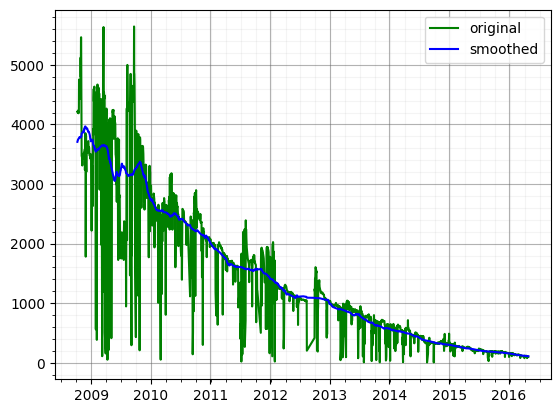

In [ ]:
# plotting the data
plt.plot(df_smoothed["date"],df_smoothed["production"],label="original",color="green")
plt.plot(df_smoothed["date"],df_smoothed["production_smoothed"],label="smoothed",color="blue")
# xlabel

plt.legend(loc="upper right")
# major grid lines
plt.grid(which="major",color="#6666",linestyle="-",alpha=.5)
# minor grid lines
plt.grid(which="minor",color="#9999",linestyle="-",alpha=.1)
# show the minor grid lines
plt.minorticks_on()

**Task 4 | Getting Days from the Date**

Goal: Using the date column, calculate the elapsed days as integer values.

Arguments: df, column_name (default is "date").

Return: A dataframe with four columns: date, production, production_smoothed, and days.

In [ ]:
# get the days as int
def get_days(df, col_name="date"):

    # calculate days from the minimum date in the series
    df["days"] = (df[col_name] - df[col_name].min()).dt.days

    return df

In [ ]:
# test the function here
df_final = get_days(df_smoothed)
df_final

/tmp/ipython-input-2853149058.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["days"] = (df[col_name] - df[col_name].min()).dt.days


,date,production,production_smoothed,days
5204,2008-10-08,4208.55,3707.905133,0
5205,2008-10-09,4201.86,3719.529533,1
5206,2008-10-10,4206.55,3738.735600,2
5207,2008-10-11,4231.88,3745.148067,3
5208,2008-10-12,4195.09,3748.176333,4
...,...,...,...,...
7878,2016-04-26,93.76,110.603600,2757
7879,2016-04-27,92.30,110.400533,2758
7880,2016-04-28,93.42,110.219933,2759
7881,2016-04-29,100.39,110.099000,2760


In [ ]:
def hyperbolic(t, qi, di, b):
    return qi / (np.abs((1 + b * di * t))**(1/b))

def exponential(t, qi, di):
    return qi * np.exp(-di * t)

def harmonic(t, qi, di):
    return qi / (1 + di * t)

# getting only the days as T, production_smoothed as Q
T = df_final["days"]
Q = df_final["production_smoothed"]

# normalize the values
# your code here

**Task 5 | Exponential Curve Fitting**

This function normalizes the data, fits the exponential model using curve_fit, and then denormalizes the resulting parameters.

In [ ]:
def exponential_fitting(T, Q):
    """fitting the exponential curve for ARP's model parameters"""

    # normalize the data
    T_normalized = T / max(T)
    Q_normalized = Q / max(Q)

    # curve fitting
    params, _ = curve_fit(exponential, T_normalized, Q_normalized)
    qi, di = params

    # denormalize the parameters
    qi = qi * max(Q)
    di = di / max(T)

    return {"qi": qi, "di": di, "b": 0}

In [ ]:
help(exponential_fitting)

Help on function exponential_fitting in module __main__:

exponential_fitting(T, Q)
    fitting the exponential curve for ARP's model parameters



In [ ]:
params = exponential_fitting(T, Q)
params

{'qi': np.float64(4242.142859336027),
 'di': np.float64(0.0009898730133505729),
 'b': 0}

In [ ]:
# Show the result on a plot
Q_exp = exponential(T, params["qi"], params["di"])

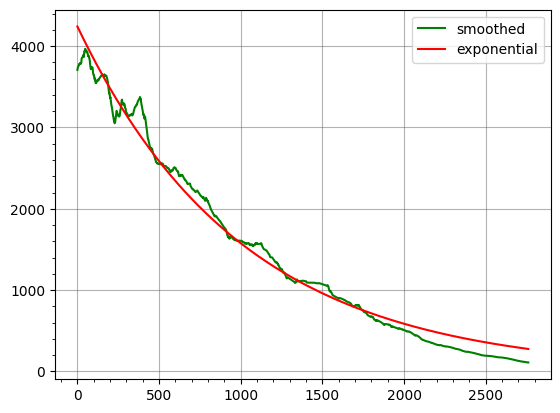

In [ ]:
# Plotting
plt.plot(T, Q, label="smoothed", color="green")
plt.plot(T, Q_exp, label="exponential", color="red")

plt.legend()
plt.grid(which="major", color="#6666", linestyle="-", alpha=.5)
plt.minorticks_on()
plt.show()

**Model Validation**

In [ ]:
def error_function(original_data, model_data):
    n = len(original_data) #
    RMSE = np.sqrt(np.sum((1/n) * np.square(original_data - model_data))) #
    return RMSE

In [ ]:
error_function(Q, Q_exp)

np.float64(134.91760757243273)

**Task 5 | Harmonic**

In [ ]:
def harmonic_fitting(T, Q):
    """fitting the harmonic curve for ARP's model parameters"""

    # normalize the data
    T_normalized = T / max(T)
    Q_normalized = Q / max(Q)

    # curve fitting
    params, _ = curve_fit(harmonic, T_normalized, Q_normalized)
    qi, di = params

    # denormalize the parameters
    qi = qi * max(Q)
    di = di / max(T)

    return {"qi": qi, "di": di, "b": 1}

In [ ]:
params_h = harmonic_fitting(T, Q)
params_h

{'qi': np.float64(4794.280911121687),
 'di': np.float64(0.0022823154779693694),
 'b': 1}

In [ ]:
Q_h = harmonic(T, params_h["qi"], params_h["di"])

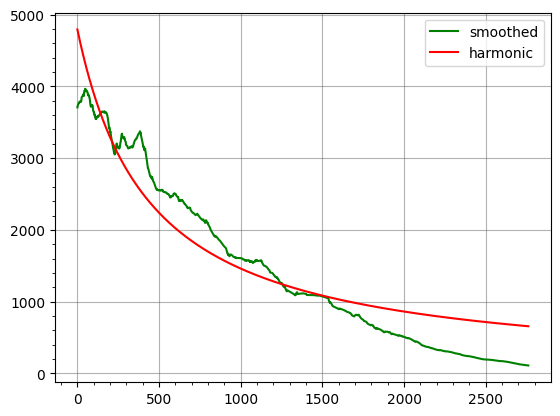

In [ ]:
# Plotting
plt.plot(T, Q, label="smoothed", color="green")
plt.plot(T, Q_h, label="harmonic", color="red")

plt.legend()
plt.grid(which="major", color="#6666", linestyle="-", alpha=.5)
plt.minorticks_on()
plt.show()

In [ ]:
RMSE_h = error_function(Q, Q_h)
RMSE_h

np.float64(373.7932657978561)

**Task 5 | Hyperbolic**

In [ ]:
def hyperbolic_fitting(T, Q):
    """fitting the harmonic curve for ARP's model parameters"""

    # normalize the data
    T_normalized = T / max(T)
    Q_normalized = Q / max(Q)

    # curve fitting
    params, _ = curve_fit(hyperbolic, T_normalized, Q_normalized)
    qi, di , b = params

    # denormalize the parameters
    qi = qi * max(Q)
    di = di / max(T)

    return {"qi": qi, "di": di, "b": b}

In [ ]:
params_hyp = hyperbolic_fitting(T, Q)
params_hyp

{'qi': np.float64(3994.22587362939),
 'di': np.float64(0.0007480059947991695),
 'b': np.float64(-0.3400567427879303)}

In [ ]:
Q_hyp = hyperbolic(T, params_hyp["qi"], params_hyp["di"], params_hyp["b"])

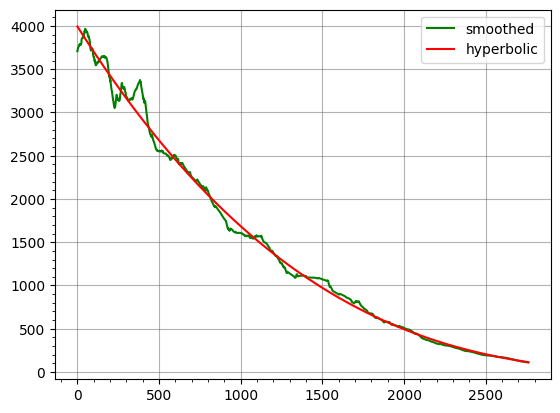

In [ ]:
# Plotting
plt.plot(T, Q, label="smoothed", color="green")
plt.plot(T, Q_hyp, label="hyperbolic", color="red")

plt.legend()
plt.grid(which="major", color="#6666", linestyle="-", alpha=.5)
plt.minorticks_on()
plt.show()

In [ ]:
RMSE_hyp = error_function(Q, Q_hyp)
RMSE_hyp

np.float64(80.73455992946633)

**Building Arp Model**

In [ ]:
def arps(df, date_col, production_smoothed_col):
    """arps model

    fitting all arps models ( exponential , harmonic , hyperbolic) and return the parameters and data for visualization

    parameters:
    -----------

    df : pd.DataFrame
        data frame with two columns [ date, production_smoothed]

    return
    ------
    models_params: dictionary
    vislualization_data : pd.DataFrame
    """

    df = get_days(df, col_name= date_col)
    T = df["days"]
    Q = df[production_smoothed_col]

    # fitting the exponential
    exp_params = exponential_fitting(T, Q)
    Q_exp = exponential(T, exp_params["qi"], exp_params["di"])
    exp_error = error_function(Q, Q_exp)

    # fitting the harmonic model
    h_params = harmonic_fitting(T, Q)
    Q_h = harmonic(T, h_params["qi"], h_params["di"])
    h_error = error_function(Q, Q_h)

    # fitting the hyperbolic model
    hyp_params = hyperbolic_fitting(T, Q)
    Q_hyp = hyperbolic(T, hyp_params["qi"], hyp_params["di"], hyp_params["b"])
    hyp_error = error_function(Q, Q_hyp)

    # visualization data
    vis_data = pd.DataFrame({
        "Time": T,
        "original": Q,
        "hyperbolic": Q_hyp,
        "harmonic": Q_h,
        "exponential": Q_exp
    }).set_index("Time")

    # params for all models
    params_dict = pd.DataFrame({
        "model": ["exponential", "harmonic", "hyperbolic"],
        "qi": [exp_params["qi"], h_params["qi"], hyp_params["qi"]],
        "di": [exp_params["di"], h_params["di"], hyp_params["di"]],
        "b": [exp_params["b"], h_params["b"], hyp_params["b"]],
        "RMSE": [exp_error, h_error, hyp_error]
    })

    # return the params and the data for the visualization
    return params_dict, vis_data

In [ ]:
params, vis_data = arps(df_smoothed, date_col="date", production_smoothed_col="production_smoothed")

/tmp/ipython-input-2853149058.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["days"] = (df[col_name] - df[col_name].min()).dt.days


In [ ]:
params

,model,qi,di,b,RMSE
0,exponential,4242.142859,0.000990,0.000000,134.917608
1,harmonic,4794.280911,0.002282,1.000000,373.793266
2,hyperbolic,3994.225874,0.000748,-0.340057,80.734560


<Axes: xlabel='Time'>

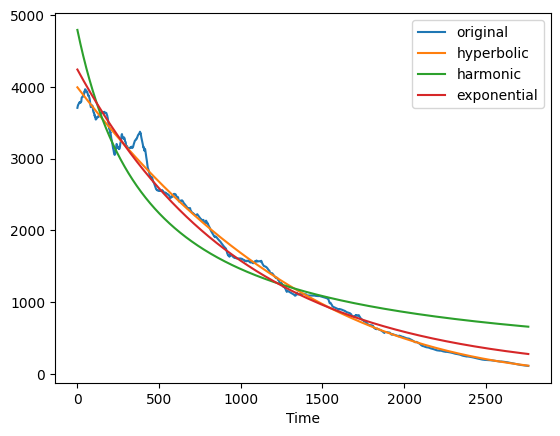

In [ ]:
vis_data.plot()